In [ ]:
!sudo apt install aria2c
!aria2c https://zenodo.org/api/records/56198/files-archive

In [2]:
!curl https://zenodo.org/api/records/56198/files-archive --output 56198.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  292M    0  292M    0     0  1645k      0 --:--:--  0:03:02 --:--:-- 2434k  0     0  1464k      0 --:--:--  0:00:46 --:--:-- 1532k21k      0 --:--:--  0:01:30 --:--:-- 1965k


In [3]:
!python train.py --dataset-dir dataset

I0000 00:00:1774091958.170569   14228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774091958.177277   14228 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774091958.848954   14228 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774091960.024657   14228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from config import TrainConfig
from data import load_formulas, load_split, Vocab, preprocess_image
from model import Im2LatexModel
from metrics import char_diff, compile_latex_formula
from utils import setup_precision, set_seed


# 1) Load config and setup
cfg_path = "outputs_fp16_small/resolved_config.json"
cfg = TrainConfig.load_json(cfg_path)
cfg.output_dir = "outputs_fp16_small"  # ensure correct path

# 2) Load formulas + test split
formulas = load_formulas(os.path.join(cfg.dataset_dir, "im2latex_formulas.lst"))
test_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_test.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)

# 3) Load vocab
vocab = Vocab.load(os.path.join(cfg.output_dir, "vocab.json"))

# 4) Build model and load weights
setup_precision(cfg.precision)
set_seed(cfg.seed)

model = Im2LatexModel(
    vocab_size=len(vocab.token_to_id),
    d_model=cfg.d_model,
    emb_dim=cfg.emb_dim,
    dec_dim=cfg.dec_dim,
    attn_dim=cfg.attn_dim,
    bos_id=vocab.bos_id,
    eos_id=vocab.eos_id,
    pad_id=vocab.pad_id,
    name="im2_latex_model",
)

dummy_images = tf.zeros([1, cfg.target_height, 128, 1], dtype=tf.float32)
dummy_tgt = tf.zeros([1, cfg.max_len - 1], dtype=tf.int32)
_ = model((dummy_images, dummy_tgt), training=False)

best_ckpt = os.path.join(cfg.output_dir, "checkpoints", "best.weights.h5")
model.load_weights(best_ckpt)
print("Loaded:", best_ckpt)

I0000 00:00:1774127672.587654  198420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774127672.588137  198420 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774127672.621289  198420 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774127673.710908  198420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Loaded: outputs_fp16_small/checkpoints/best.weights.h5


In [ ]:
import cv2
from viz import overlay_attention  # if you have viz.py; otherwise copy overlayAttention code here

def visualize_samples_inline(sample_indices, max_len=None):
    if max_len is None:
        max_len = cfg.max_len - 1

    n = len(sample_indices)
    plt.figure(figsize=(12, 4 * n))

    for i, idx in enumerate(sample_indices):
        sample = test_samples[idx]
        img = preprocess_image(
            sample["image_path"],
            # target_height=cfg.target_height,
            # max_width=cfg.max_width,
            scale_factor=cfg.scale_factor,
        )
        # img = preprocess_image(img, scale_factor=cfg.scale_factor)

        batch = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
        pred_ids, attn = model.greedy_decode(batch, max_len=max_len)

        pred_formula = vocab.decode(pred_ids[0].numpy())
        gt_formula = sample["formula"]
        avg_attn = tf.reduce_mean(attn[0], axis=0).numpy()
        compiles, _ = compile_latex_formula(pred_formula)
        diff = char_diff(gt_formula, pred_formula)

        # attn_img = overlay_attention(img, avg_attn)
        batch = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
        pred_ids, attn = model.greedy_decode(batch, max_len=cfg.max_len - 1)

        avg_attn = tf.reduce_mean(attn[0], axis=0).numpy()  # shape [H_f, W_f]
        attn_img = overlay_attention(img, avg_attn)

        # 2 columns: input and attention overlay
        ax1 = plt.subplot(n, 2, 2 * i + 1)
        ax2 = plt.subplot(n, 2, 2 * i + 2)

        ax1.imshow(img.squeeze(), cmap="gray")
        # ax1.set_title(f"Input idx={idx}")
        ax1.axis("off")

        ax2.imshow(attn_img)
        ax2.set_title(
            f"GT: {gt_formula}\n"
            f"PRED: {pred_formula}\n"
            f"COMPILES: {compiles}\n"
            f"DIFF: {diff}",
            fontsize=9
        )
        ax2.axis("off")

    plt.tight_layout()
    plt.show()


In [4]:
test_samples

[{'image_path': 'dataset/formatted/7944775fc9.png',
  'formula': 'i\\Delta ^{ab}(q)=\\frac{-i\\delta ^{ab}}{q^2-\\mu ^2+i\\varepsilon }',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/78228211ca.png',
  'formula': '{\\cal A}_{n} : = \\langle \\prod_{j=1}^{m} S^{k_j}_{-l_j} |\\sum_{j=1}^{m} l_j \\geq n \\rangle\\,,',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/15b9034ba8.png',
  'formula': '\\label{fierep}P_{(2)}^-=\\int \\beta d\\beta d^9p d^8\\lambda \\Phi(-p,-\\lambda)\\left(-\\frac{p^Ip^I}{2\\beta}\\right) \\Phi(p,\\lambda)\\,.',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/6968dfca15.png',
  'formula': '{\\bf E} \\rightarrow - c {{\\bf B}^{\\prime}}\\hspace{1.0in}   c {\\bf B} \\rightarrow {{\\bf E}^{\\prime}}',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/6cead0df53.png',
  'formula': 'a^{2}=\\frac{m\\mu }{k^{2}e\\lambda ^{2}_{\\phi }}\\, .',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/5381b22df4

In [ ]:
def visualize_samples_inline(sample_indices, max_len=None):
    if max_len is None:
        max_len = cfg.max_len - 1

    n = len(sample_indices)
    plt.figure(figsize=(10, 3 * n))

    for i, idx in enumerate(sample_indices):
        sample = test_samples[idx]
        img = preprocess_image(
            sample["image_path"],
            target_height=cfg.target_height,
            max_width=cfg.max_width,
            scale_factor=cfg.scale_factor,
        )

        batch = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
        pred_ids, attn = model.greedy_decode(batch, max_len=max_len)

        pred_formula = vocab.decode(pred_ids[0].numpy())
        gt_formula = sample["formula"]
        avg_attn = tf.reduce_mean(attn[0], axis=0).numpy()
        compiles, _ = compile_latex_formula(pred_formula)
        diff = char_diff(gt_formula, pred_formula)

        blended = overlay_attention(img, avg_attn)

        ax = plt.subplot(n, 1, i + 1)
        ax.imshow(blended)
        ax.set_title(
            f"idx={idx}  COMPILES: {compiles}\n"
            f"GT:   {gt_formula}\n"
            f"PRED: {pred_formula}\n"
            f"DIFF: {diff}",
            fontsize=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
np.random.seed(0)
indices = np.random.choice(len(test_samples), size=3, replace=False)
visualize_samples_inline(indices)


In [7]:
model.summary()

Model: "im2_latex_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_encoder (CNNEncoder)        │ ?                      │     2,144,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ row_encoder (RowEncoder)        │ ?                      │       362,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (AttentionDecoder)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,571,233 (13.62 MB)

 Trainable params: 3,568,801 (13.61 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
img = preprocess_image(..., scale_factor=cfg.scale_factor)
batch = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
pred_ids, attn = model.greedy_decode(batch, max_len=cfg.max_len - 1)

avg_attn = tf.reduce_mean(attn[0], axis=0).numpy()  # shape [H_f, W_f]
attn_img = overlay_attention(img, avg_attn)

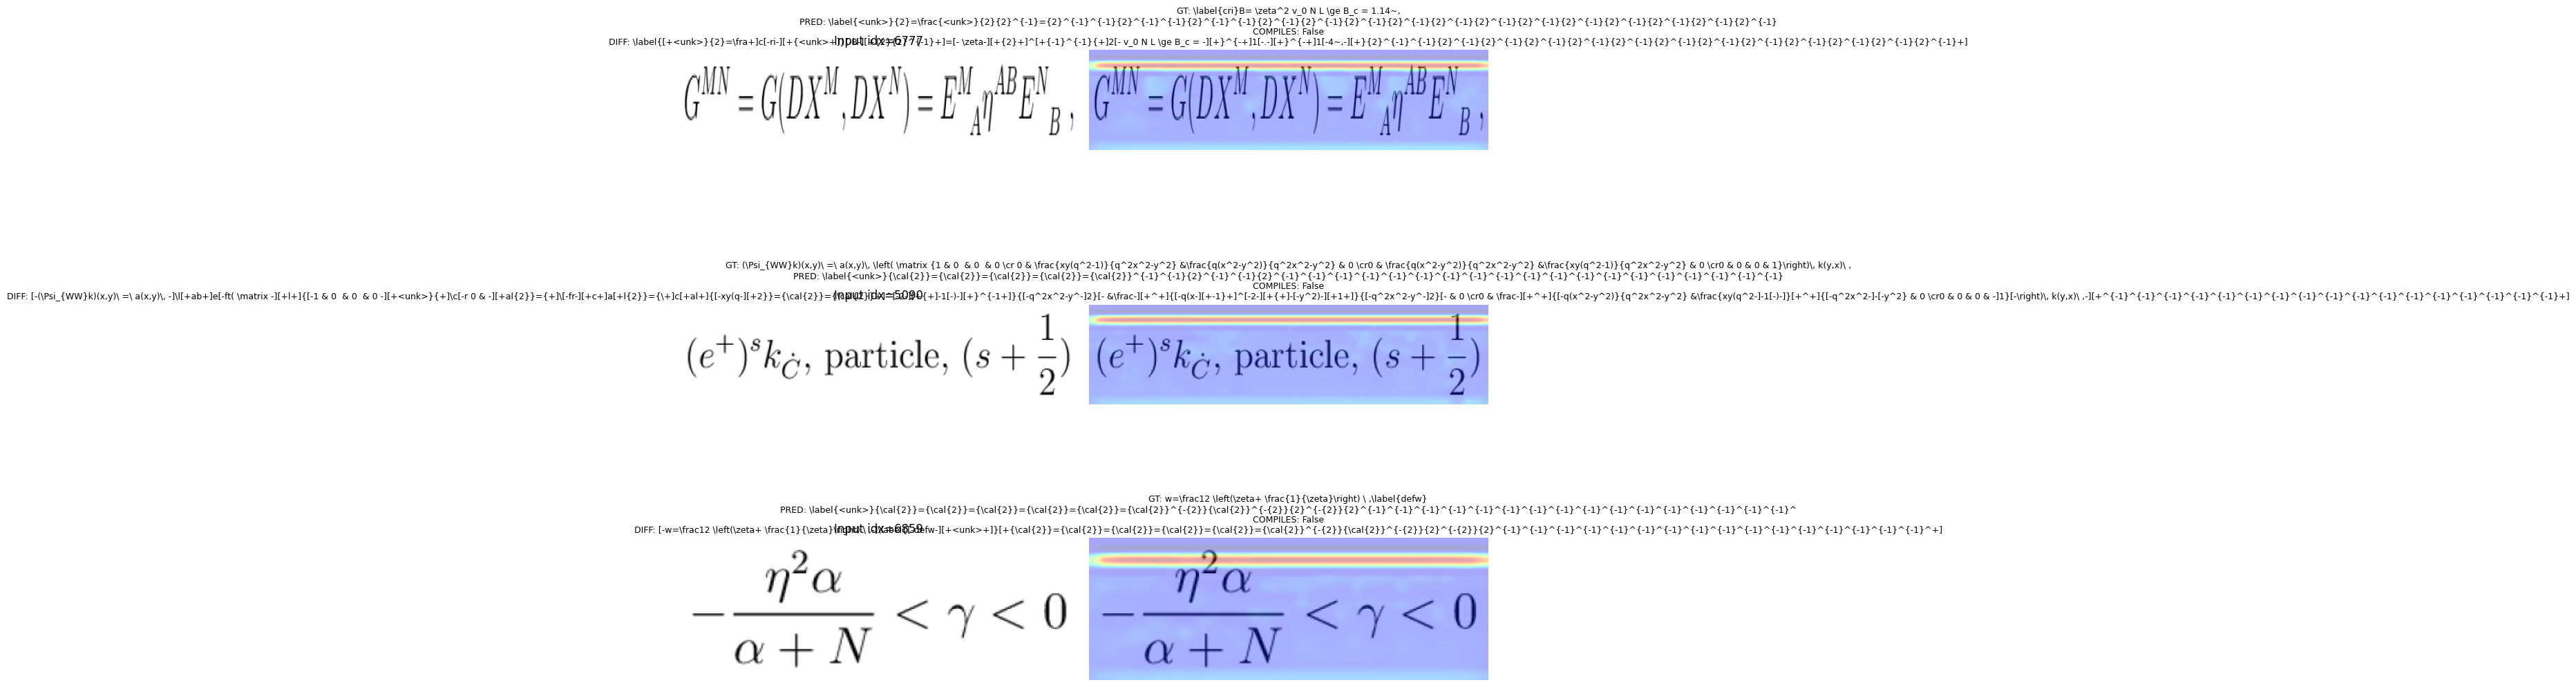

In [13]:
np.random.seed(0)
indices = np.random.choice(len(test_samples), size=3, replace=False)

visualize_samples_inline(indices)
